In [107]:
import yfinance as yf
from datetime import datetime
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Conv1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import Huber
import matplotlib.pyplot as plt
import seaborn as sns

# Fetch data

In [108]:
tickers_btc_eth = yf.Tickers('BTC-USD ETH-USD')
tickers_au_si = yf.Tickers('SI=F GC=F')
tickers_sp500 = yf.Tickers('QQQ')

data_btc_eth = tickers_btc_eth.history(period='1y', interval='1h')
data_au_si = tickers_au_si.history(period='1y', interval='1h')
data_sp500 = tickers_sp500.history(period='1y', interval='1h')

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed


In [109]:
data_btc_eth.head()

Price                             Close              Dividends          \
Ticker                          BTC-USD      ETH-USD   BTC-USD ETH-USD   
Datetime                                                                 
2025-04-13 20:00:00+00:00  83457.804688  1592.945190       0.0     0.0   
2025-04-13 21:00:00+00:00  83598.812500  1594.144531       0.0     0.0   
2025-04-13 22:00:00+00:00  83304.406250  1586.685059       0.0     0.0   
2025-04-13 23:00:00+00:00  83702.351562  1597.018433       0.0     0.0   
2025-04-14 00:00:00+00:00  84258.570312  1610.819092       0.0     0.0   

Price                              High                        Low  \
Ticker                          BTC-USD      ETH-USD       BTC-USD   
Datetime                                                             
2025-04-13 20:00:00+00:00  84331.765625  1611.565918  83247.078125   
2025-04-13 21:00:00+00:00  83734.609375  1594.420532  83037.500000   
2025-04-13 22:00:00+00:00  83741.367188  1596.584595  83154.562500   
2025-04-13 23:00:00+00:00  83747.453125  1598.669800  83206.085938   
2025-04-14 00:00:00+00:00  84921.476562  1625.206177  83706.945312   

Price                                           Open               \
Ticker                         ETH-USD       BTC-USD      ETH-USD   
Datetime                                                            
2025-04-13 20:00:00+00:00  1586.989746  83926.843750  1588.650879   
2025-04-13 21:00:00+00:00  1575.274170  83477.539062  1590.323486   
2025-04-13 22:00:00+00:00  1584.307007  83560.414062  1593.419800   
2025-04-13 23:00:00+00:00  1583.370239  83306.179688  1585.783936   
2025-04-14 00:00:00+00:00  1596.095093  83714.000000  1596.836792   

Price                     Stock Splits              Volume              
Ticker                         BTC-USD ETH-USD     BTC-USD     ETH-USD  
Datetime                                                                
2025-04-13 20:00:00+00:00          0.0     0.0           0           0  
2025-04-13 21:00:00+00:00          0.0     0.0           0           0  
2025-04-13 22:00:00+00:00          0.0     0.0  1234771968  1746874368  
2025-04-13 23:00:00+00:00          0.0     0.0           0           0  
2025-04-14 00:00:00+00:00          0.0     0.0  1344247808   659018752

In [110]:
data_au_si.head()

Price                            Close            Dividends              High  \
Ticker                            GC=F       SI=F      GC=F SI=F         GC=F   
Datetime                                                                        
2025-04-13 22:00:00+00:00  3238.199951  31.980000       0.0  0.0  3250.000000   
2025-04-13 23:00:00+00:00  3240.699951  32.025002       0.0  0.0  3241.500000   
2025-04-14 00:00:00+00:00  3238.000000  31.905001       0.0  0.0  3244.399902   
2025-04-14 01:00:00+00:00  3256.199951  31.940001       0.0  0.0  3259.800049   
2025-04-14 02:00:00+00:00  3248.000000  31.825001       0.0  0.0  3261.600098   

Price                                         Low                    Open  \
Ticker                          SI=F         GC=F       SI=F         GC=F   
Datetime                                                                    
2025-04-13 22:00:00+00:00  32.255001  3215.500000  31.940001  3246.000000   
2025-04-13 23:00:00+00:00  32.044998  3233.699951  31.915001  3238.000000   
2025-04-14 00:00:00+00:00  32.095001  3236.100098  31.905001  3240.399902   
2025-04-14 01:00:00+00:00  32.005001  3231.800049  31.770000  3238.199951   
2025-04-14 02:00:00+00:00  32.029999  3228.800049  31.805000  3255.800049   

Price                                Stock Splits      Volume          
Ticker                          SI=F         GC=F SI=F   GC=F    SI=F  
Datetime                                                               
2025-04-13 22:00:00+00:00  32.195000          0.0  0.0   5777  1567.0  
2025-04-13 23:00:00+00:00  31.969999          0.0  0.0   2981   675.0  
2025-04-14 00:00:00+00:00  32.025002          0.0  0.0   3573  1258.0  
2025-04-14 01:00:00+00:00  31.910000          0.0  0.0  10297  2699.0  
2025-04-14 02:00:00+00:00  31.940001          0.0  0.0   7283  1259.0

In [111]:
# change dates to full hours
data_sp500.index = data_sp500.index.floor('h')
data_sp500.head()

Price,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,QQQ,QQQ,QQQ,QQQ,QQQ,QQQ,QQQ,QQQ
Datetime,,,,,,,,
2025-04-14 13:00:00+00:00,0.0,462.160004,0.0,465.049988,458.631805,464.559998,0.0,11650092
2025-04-14 14:00:00+00:00,0.0,457.600006,0.0,463.549988,457.529999,462.170013,0.0,5882938
2025-04-14 15:00:00+00:00,0.0,454.470001,0.0,458.720001,452.630005,457.630005,0.0,6890603
2025-04-14 16:00:00+00:00,0.0,455.649994,0.0,457.014801,453.500000,454.464996,0.0,4146256
2025-04-14 17:00:00+00:00,0.0,458.854401,0.0,459.019989,454.739990,455.640015,0.0,3649113


In [112]:
data_btc_eth = data_btc_eth.drop(columns=['Dividends', 'Stock Splits'])
data_au_si = data_au_si.drop(columns=['Dividends', 'Stock Splits'])
data_sp500 = data_sp500.drop(columns=['Dividends', 'Stock Splits'])
data_btc_eth = data_btc_eth.dropna()
data_au_si = data_au_si.dropna()
data_sp500 = data_sp500.dropna()
data_btc_eth.columns = ['_'.join(map(str, col)).strip() for col in data_btc_eth.columns]
data_au_si.columns = ['_'.join(map(str, col)).strip() for col in data_au_si.columns]
data_sp500.columns = ['_'.join(map(str, col)).strip() for col in data_sp500.columns]

In [113]:
#concat dataframes indexes with all columns, only rows with all data
data = pd.concat([data_btc_eth, data_au_si, data_sp500], axis=1, join='inner')
data.head()

,Close_BTC-USD,Close_ETH-USD,High_BTC-USD,High_ETH-USD,Low_BTC-USD,Low_ETH-USD,Open_BTC-USD,Open_ETH-USD,Volume_BTC-USD,Volume_ETH-USD,...,Open_GC=F,Open_SI=F,Volume_GC=F,Volume_SI=F,Capital Gains_QQQ,Close_QQQ,High_QQQ,Low_QQQ,Open_QQQ,Volume_QQQ
Datetime,,,,,,,,,,,,,,,,,,,,,
2025-04-14 13:00:00+00:00,84460.976562,1659.810913,85243.421875,1679.285522,84098.703125,1649.760864,85094.320312,1676.056763,0,0,...,3223.199951,32.09,21212,10823.0,0.0,462.160004,465.049988,458.631805,464.559998,11650092
2025-04-14 14:00:00+00:00,85450.148438,1673.895630,85766.500000,1687.735596,84345.437500,1658.103516,84370.648438,1658.103516,1517629440,892588032,...,3221.100098,31.92,13783,5072.0,0.0,457.600006,463.549988,457.529999,462.170013,5882938
2025-04-14 15:00:00+00:00,84114.812500,1628.247925,85423.507812,1673.515991,83778.320312,1624.174316,85423.507812,1673.515991,2166917120,552222720,...,3227.800049,32.07,13594,3150.0,0.0,454.470001,458.720001,452.630005,457.630005,6890603
2025-04-14 16:00:00+00:00,84367.968750,1628.802246,84612.414062,1634.564575,83876.304688,1619.926636,84089.757812,1627.841309,83849216,123895808,...,3214.699951,31.93,7653,2019.0,0.0,455.649994,457.014801,453.500000,454.464996,4146256
2025-04-14 17:00:00+00:00,84874.984375,1647.518921,84874.984375,1648.030762,84244.820312,1627.973877,84344.875000,1628.347778,0,0,...,3223.399902,32.00,9098,4422.0,0.0,458.854401,459.019989,454.739990,455.640015,3649113


In [138]:
data['btc_return_close'] = data['Close_BTC-USD'].shift(1).pct_change()
data['btc_volume_change'] = data['Volume_BTC-USD'].shift(1).pct_change()
data['eth_return_close'] = data['Close_ETH-USD'].shift(1).pct_change()
data['eth_volume_change'] = data['Volume_ETH-USD'].shift(1).pct_change()
data['si_return_close'] = data['Close_SI=F'].shift(1).pct_change()
data['gc_return_close'] = data['Close_GC=F'].shift(1).pct_change()
data['sp500_return_close'] = data['Close_QQQ'].shift(1).pct_change()
data['y'] = (data['btc_return_close'].shift(-1) > 0).astype(int)
data = data.dropna()
data = data.replace([np.inf, -np.inf], np.nan).dropna()
data.head()

,Close_BTC-USD,Close_ETH-USD,High_BTC-USD,High_ETH-USD,Low_BTC-USD,Low_ETH-USD,Open_BTC-USD,Open_ETH-USD,Volume_BTC-USD,Volume_ETH-USD,...,Open_QQQ,Volume_QQQ,btc_return_close,eth_return_close,si_return_close,gc_return_close,sp500_return_close,btc_volume_change,eth_volume_change,y
Datetime,,,,,,,,,,,,,,,,,,,,,
2025-04-17 13:00:00+00:00,84406.187500,1591.971558,84754.046875,1601.025635,84344.382812,1590.169678,84754.046875,1601.025635,0,0,...,447.130005,9528233,0.004121,0.015203,-0.002892,-0.000477,0.013784,-0.855755,-0.775039,1
2025-04-17 17:00:00+00:00,85147.125000,1610.198486,85190.132812,1614.437012,84825.437500,1601.851929,84932.648438,1605.232910,0,0,...,444.000000,4110390,0.000282,0.000995,-0.007328,-0.007190,-0.003216,-1.000000,-1.000000,1
2025-04-21 17:00:00+00:00,86798.789062,1576.593750,87288.585938,1589.048584,86410.585938,1575.031860,87146.601562,1589.048584,2301939712,811513856,...,429.051514,3411834,-0.001086,-0.003952,0.002145,0.001546,-0.002893,-0.741953,-1.000000,0
2025-04-21 19:00:00+00:00,87380.062500,1574.962646,87462.585938,1580.265625,86743.718750,1568.289673,86806.648438,1568.289673,1384026112,1634665472,...,429.779999,8437480,0.000308,-0.004320,0.000767,0.000844,0.001303,-0.184421,0.740763,1
2025-04-22 13:00:00+00:00,90104.265625,1639.267456,90468.250000,1652.652100,89001.187500,1630.164551,89001.187500,1635.376465,3978575872,383673344,...,438.880005,9438370,0.006387,0.003300,0.002146,-0.000727,0.008169,-0.262802,0.157160,1


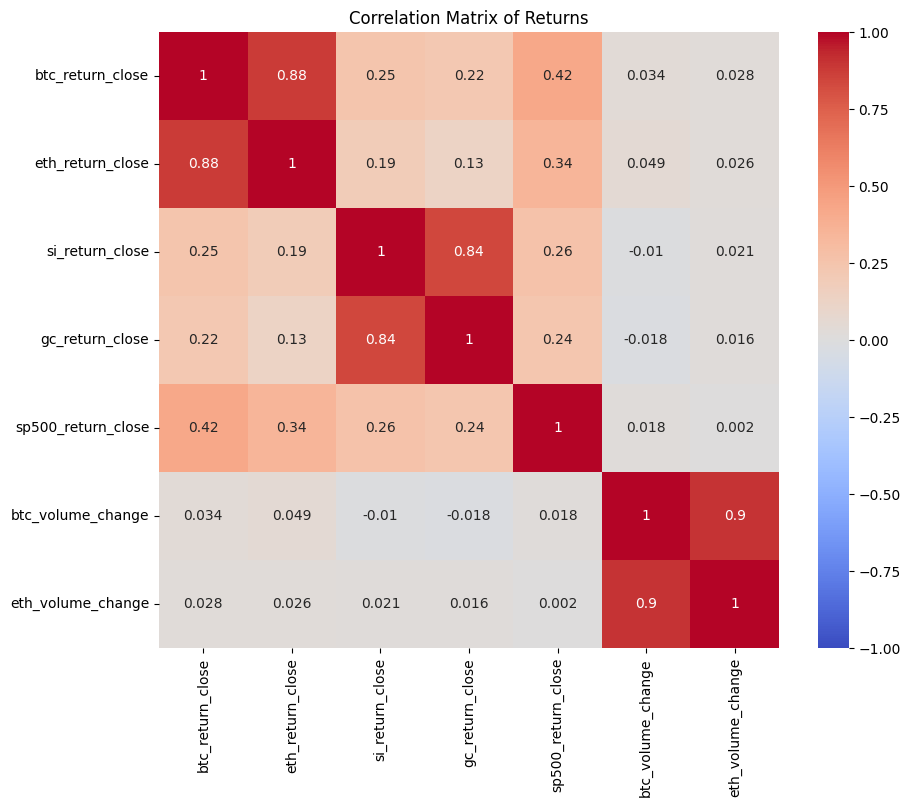

,btc_return_close,eth_return_close,si_return_close,gc_return_close,sp500_return_close,btc_volume_change,eth_volume_change
count,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000
mean,0.000188,0.000533,0.000728,0.000113,0.000330,0.682772,5.110520
std,0.010235,0.015687,0.014609,0.007068,0.004203,9.306325,90.993951
min,-0.070721,-0.127493,-0.148385,-0.066804,-0.017550,-1.000000,-1.000000
25%,-0.003614,-0.004545,-0.002261,-0.001267,-0.001460,-1.000000,-1.000000
50%,-0.000111,0.000436,0.000956,0.000333,0.000324,-0.441534,-0.600771
75%,0.004059,0.006032,0.004242,0.002151,0.001747,0.135352,0.247305
max,0.073004,0.099005,0.063666,0.028736,0.019849,173.164675,1870.687050


In [147]:
# Correlation matrix of returns
returns = data[['btc_return_close', 'eth_return_close', 'si_return_close', 'gc_return_close', 'sp500_return_close', 'btc_volume_change', 'eth_volume_change']]
corr_matrix = returns.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Returns')
plt.show()
returns.describe()

In [143]:
ready_data = data[['btc_return_close', 'eth_return_close', 'si_return_close', 'gc_return_close', 'sp500_return_close', 'y']]
ready_data.head()

,btc_return_close,eth_return_close,si_return_close,gc_return_close,sp500_return_close,y
Datetime,,,,,,
2025-04-17 13:00:00+00:00,0.004121,0.015203,-0.002892,-0.000477,0.013784,1
2025-04-17 17:00:00+00:00,0.000282,0.000995,-0.007328,-0.007190,-0.003216,1
2025-04-21 17:00:00+00:00,-0.001086,-0.003952,0.002145,0.001546,-0.002893,0
2025-04-21 19:00:00+00:00,0.000308,-0.004320,0.000767,0.000844,0.001303,1
2025-04-22 13:00:00+00:00,0.006387,0.003300,0.002146,-0.000727,0.008169,1


In [144]:
model = Sequential()
model.add(Input(shape=(ready_data.drop('y', axis=1).shape[1], 1)))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 3, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 3, 50)          │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 3, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,558 (170.15 KB)

 Trainable params: 43,558 (170.15 KB)

 Non-trainable params: 0 (0.00 B)

In [145]:
X_data = ready_data.drop(columns=['y'])
y_data = ready_data['y']
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [146]:
model.fit(X_train.values.reshape(-1, X_train.shape[1], 1), y_train.values.reshape(-1, 1), validation_data=(X_val.values.reshape(-1, X_val.shape[1], 1), y_val.values.reshape(-1, 1)), epochs=50, batch_size=32, callbacks=[EarlyStopping(monitor='val_accuracy', patience=5)])

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.4926 - loss: 0.6937 - val_accuracy: 0.4762 - val_loss: 0.6934
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4779 - loss: 0.6934 - val_accuracy: 0.5238 - val_loss: 0.6929
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5015 - loss: 0.6932 - val_accuracy: 0.5238 - val_loss: 0.6929
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5044 - loss: 0.6933 - val_accuracy: 0.5238 - val_loss: 0.6929
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5074 - loss: 0.6937 - val_accuracy: 0.5238 - val_loss: 0.6925
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5074 - loss: 0.6930 - val_accuracy: 0.5238 - val_loss: 0.6925
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5074 - loss: 0.6931 - val_accuracy: 0.5238 - val_loss: 0.6925
